In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
wluna = pd.read_csv("../data/wluna_price_data.csv")

In [3]:
wluna['datetime'] = pd.to_datetime(wluna['timestamp'], unit = 's').dt.date
wluna.drop(columns=['timestamp'])
wluna.head()


,timestamp,open,high,low,close,datetime
0,1648857600,103.23,107.28,100.03,105.87,2022-04-02
1,1648944000,105.90,116.74,105.72,115.49,2022-04-03
2,1649030400,115.46,116.99,112.02,113.46,2022-04-04
3,1649116800,113.40,116.41,110.36,115.96,2022-04-05
4,1649203200,115.99,118.19,115.52,116.10,2022-04-06


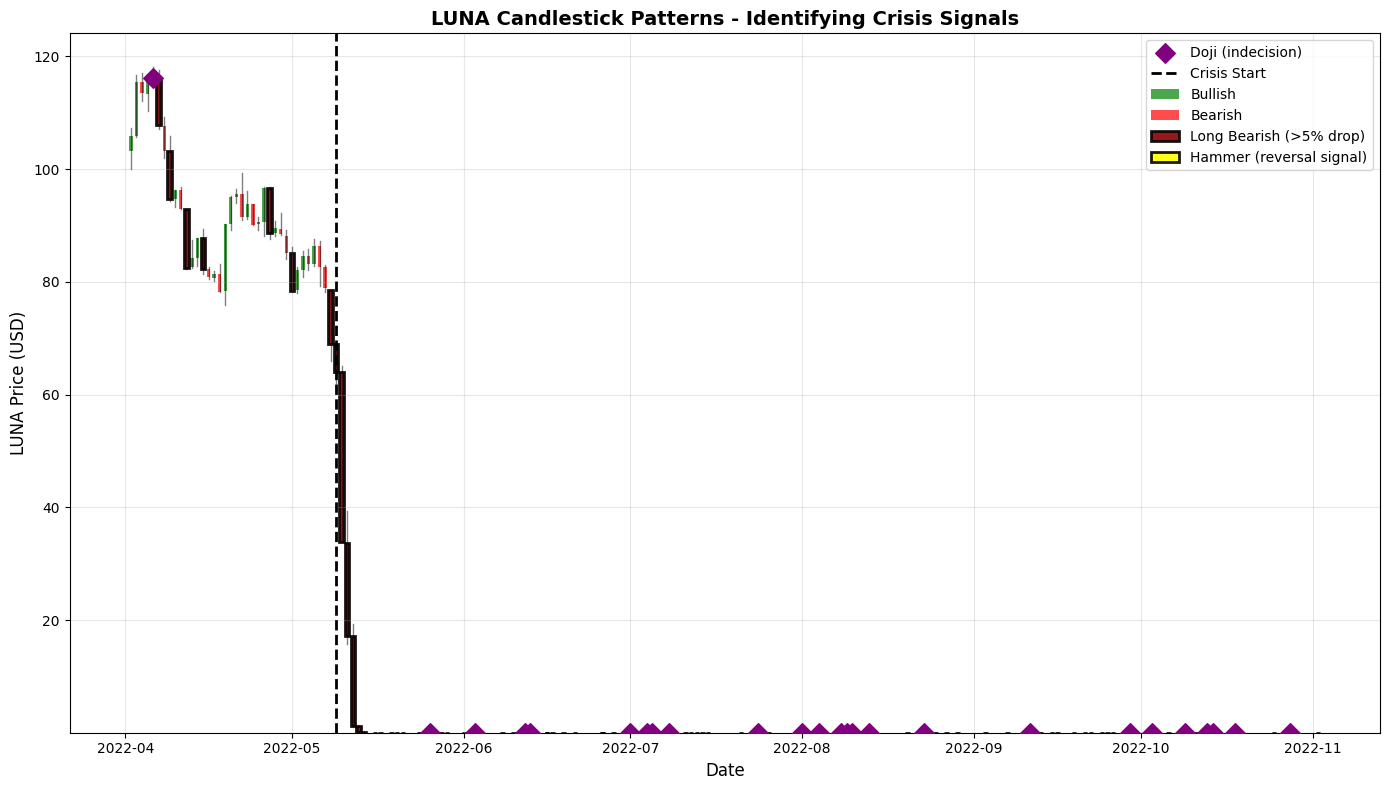

In [4]:
# ========== STEP 1: Calculate candlestick patterns ==========
# Determine candle components
wluna['body'] = abs(wluna['close'] - wluna['open'])
wluna['upper_shadow'] = wluna['high'] - wluna[['open', 'close']].max(axis=1)
wluna['lower_shadow'] = wluna[['open', 'close']].min(axis=1) - wluna['low']

# Bullish or bearish?
wluna['candle_type'] = wluna.apply(
    lambda row: 'bullish' if row['close'] > row['open'] else 'bearish', 
    axis=1
)

# Long bearish candles (5%+ drop)
wluna['long_bearish'] = (wluna['open'] - wluna['close']) / wluna['open'] > 0.05

# Doji (indecision - small body relative to range)
wluna['doji'] = abs(wluna['close'] - wluna['open']) / (wluna['high'] - wluna['low']) < 0.1

# Hammer (potential reversal - long lower shadow)
wluna['hammer'] = (
    (wluna['lower_shadow'] > 2 * wluna['body']) &  # Long lower shadow
    (wluna['upper_shadow'] < wluna['body'])  # Short upper shadow
)

# ========== STEP 2: Now create the plot ==========
fig, ax = plt.subplots(figsize=(14, 8))

# Base candlesticks
bullish = wluna['close'] >= wluna['open']
bearish = wluna['close'] < wluna['open']

# Normal candles
ax.bar(wluna.loc[bullish & ~wluna['hammer'], 'datetime'], 
       wluna.loc[bullish & ~wluna['hammer'], 'close'] - wluna.loc[bullish & ~wluna['hammer'], 'open'],
       bottom=wluna.loc[bullish & ~wluna['hammer'], 'open'],
       color='green', width=0.6, alpha=0.7, label='Bullish')

ax.bar(wluna.loc[bearish & ~wluna['long_bearish'], 'datetime'],
       wluna.loc[bearish & ~wluna['long_bearish'], 'open'] - wluna.loc[bearish & ~wluna['long_bearish'], 'close'],
       bottom=wluna.loc[bearish & ~wluna['long_bearish'], 'close'],
       color='red', width=0.6, alpha=0.7, label='Bearish')

# Highlight LONG BEARISH candles (>5% drop)
if wluna['long_bearish'].any():
    ax.bar(wluna.loc[wluna['long_bearish'], 'datetime'],
           wluna.loc[wluna['long_bearish'], 'open'] - wluna.loc[wluna['long_bearish'], 'close'],
           bottom=wluna.loc[wluna['long_bearish'], 'close'],
           color='darkred', width=0.8, alpha=0.9, label='Long Bearish (>5% drop)', 
           edgecolor='black', linewidth=2)

# Highlight HAMMER candles (potential reversal)
if wluna['hammer'].any():
    hammer_data = wluna.loc[wluna['hammer']].copy()
    ax.bar(hammer_data['datetime'],
           abs(hammer_data['close'] - hammer_data['open']),
           bottom=hammer_data[['open', 'close']].min(axis=1),
           color='yellow', width=0.8, alpha=0.9, label='Hammer (reversal signal)',
           edgecolor='black', linewidth=2)

# Highlight DOJI candles (indecision)
if wluna['doji'].any():
    ax.scatter(wluna.loc[wluna['doji'], 'datetime'],
               wluna.loc[wluna['doji'], 'close'],
               color='purple', s=100, marker='D', label='Doji (indecision)', zorder=5)

# Add wicks
for idx, row in wluna.iterrows():
    ax.plot([row['datetime'], row['datetime']], 
            [row['low'], row['high']], 
            color='black', linewidth=1, alpha=0.5)

# Formatting
ax.axvline(x=pd.Timestamp('2022-05-09'), color='black', linestyle='--', linewidth=2, label='Crisis Start')
ax.set_ylabel('LUNA Price (USD)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.set_title('LUNA Candlestick Patterns - Identifying Crisis Signals', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

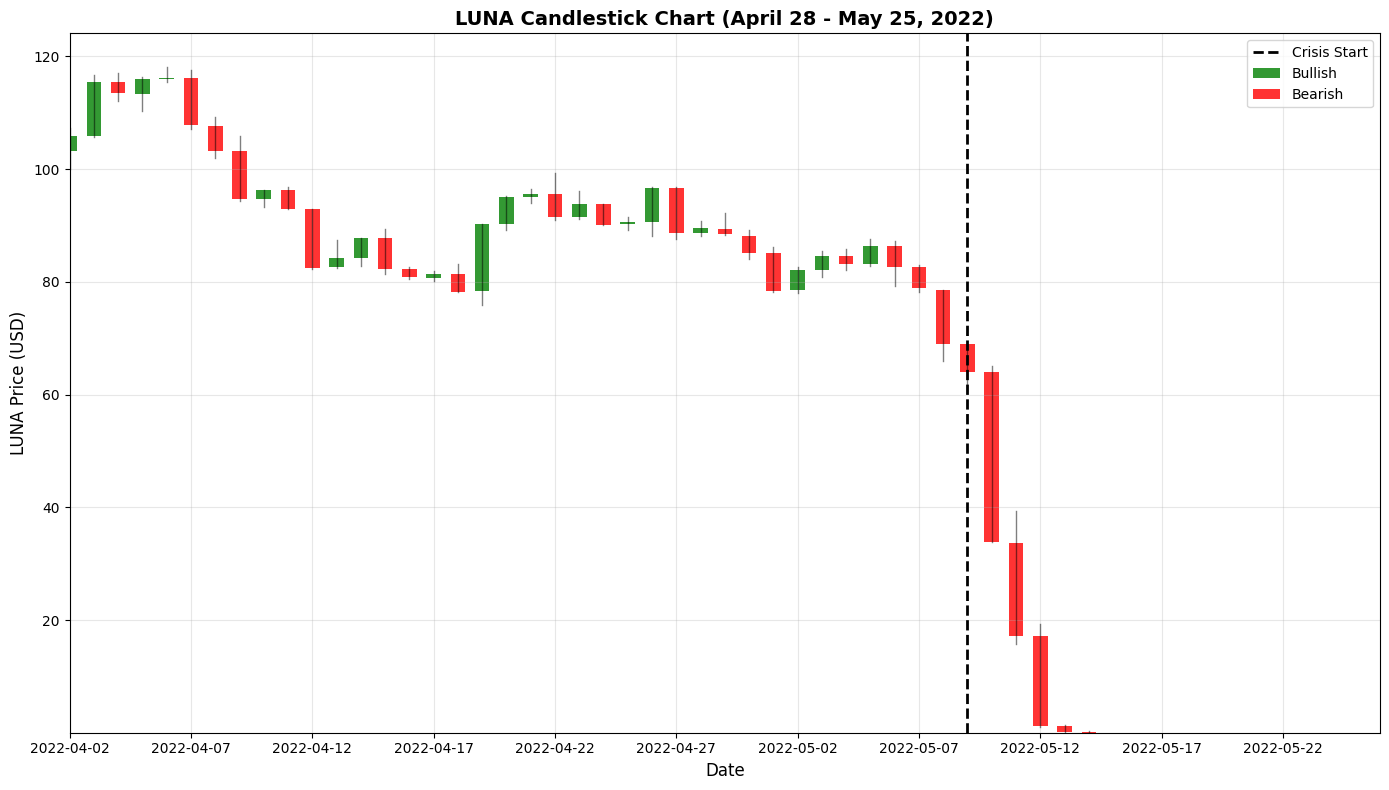

In [5]:
# Simple candlestick plot - just bullish and bearish
fig, ax = plt.subplots(figsize=(14, 8))

# Plot bullish candles (green)
ax.bar(wluna.loc[bullish, 'datetime'], 
       wluna.loc[bullish, 'close'] - wluna.loc[bullish, 'open'],
       bottom=wluna.loc[bullish, 'open'],
       color='green', width=0.6, alpha=0.8, label='Bullish')

# Plot bearish candles (red)
ax.bar(wluna.loc[bearish, 'datetime'],
       wluna.loc[bearish, 'open'] - wluna.loc[bearish, 'close'],
       bottom=wluna.loc[bearish, 'close'],
       color='red', width=0.6, alpha=0.8, label='Bearish')

# Add wicks (high-low shadows)
for idx, row in wluna.iterrows():
    ax.plot([row['datetime'], row['datetime']], 
            [row['low'], row['high']], 
            color='black', linewidth=1, alpha=0.5)

# Mark crisis start
ax.axvline(x=pd.Timestamp('2022-05-09'), color='black', linestyle='--', linewidth=2, label='Crisis Start')

# Formatting
ax.set_ylabel('LUNA Price (USD)', fontsize=12)
ax.set_xticks(wluna.datetime[::5])
ax.set_xlim(pd.Timestamp('2022-04-02'), pd.Timestamp('2022-05-26'))
ax.set_xlabel('Date', fontsize=12)
ax.set_title('LUNA Candlestick Chart (April 28 - May 25, 2022)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

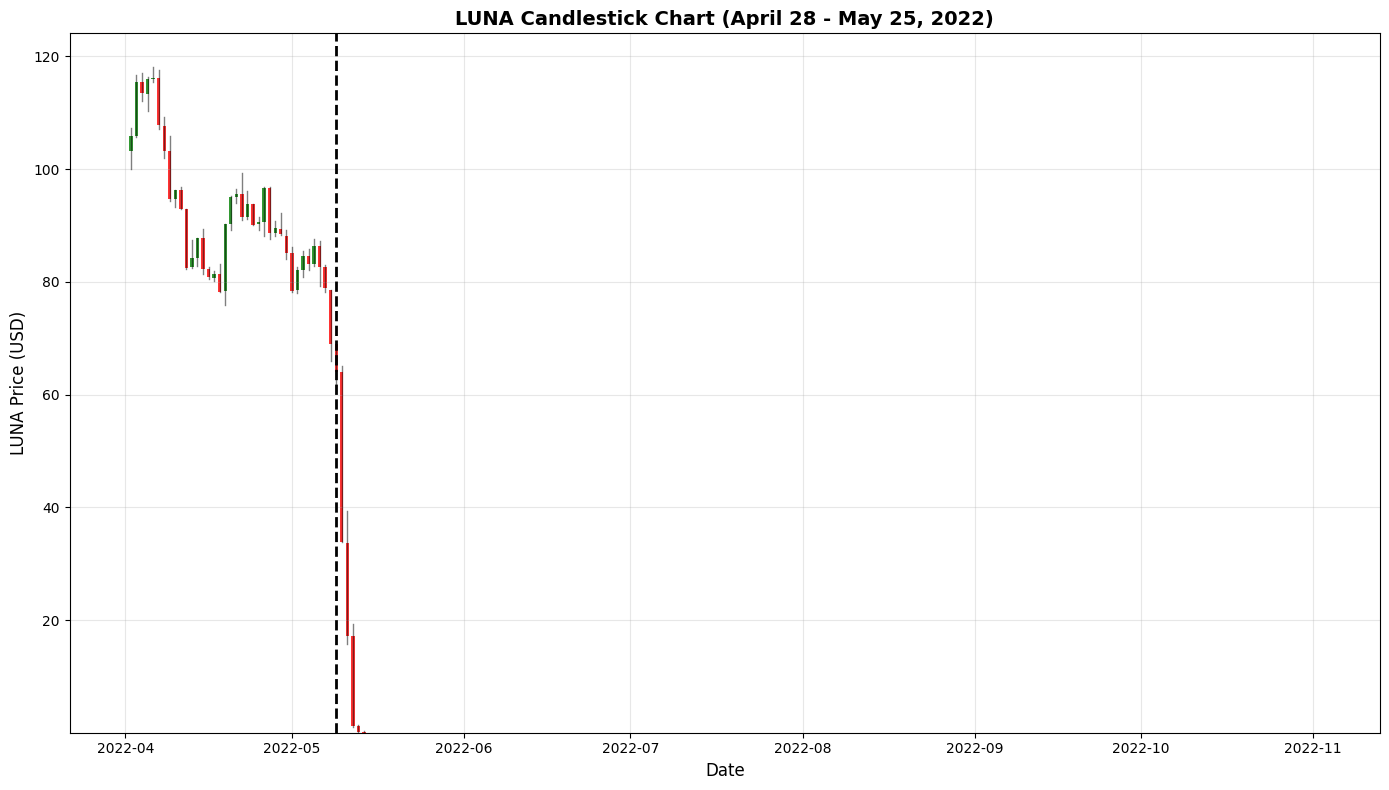

In [6]:
# Use full wluna but just zoom the plot
fig, ax = plt.subplots(figsize=(14, 8))

bullish = wluna['close'] >= wluna['open']
bearish = wluna['close'] < wluna['open']

ax.bar(wluna.loc[bullish, 'datetime'], 
       wluna.loc[bullish, 'close'] - wluna.loc[bullish, 'open'],
       bottom=wluna.loc[bullish, 'open'],
       color='green', width=0.6, alpha=0.8)

ax.bar(wluna.loc[bearish, 'datetime'],
       wluna.loc[bearish, 'open'] - wluna.loc[bearish, 'close'],
       bottom=wluna.loc[bearish, 'close'],
       color='red', width=0.6, alpha=0.8)

# Add wicks
for idx, row in wluna.iterrows():
    ax.plot([row['datetime'], row['datetime']], 
            [row['low'], row['high']], 
            color='black', linewidth=1, alpha=0.5)

# Set x-axis limits to your date range
ax.axvline(x=pd.Timestamp('2022-05-09'), color='black', linestyle='--', linewidth=2)
ax.set_ylabel('LUNA Price (USD)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.set_title('LUNA Candlestick Chart (April 28 - May 25, 2022)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

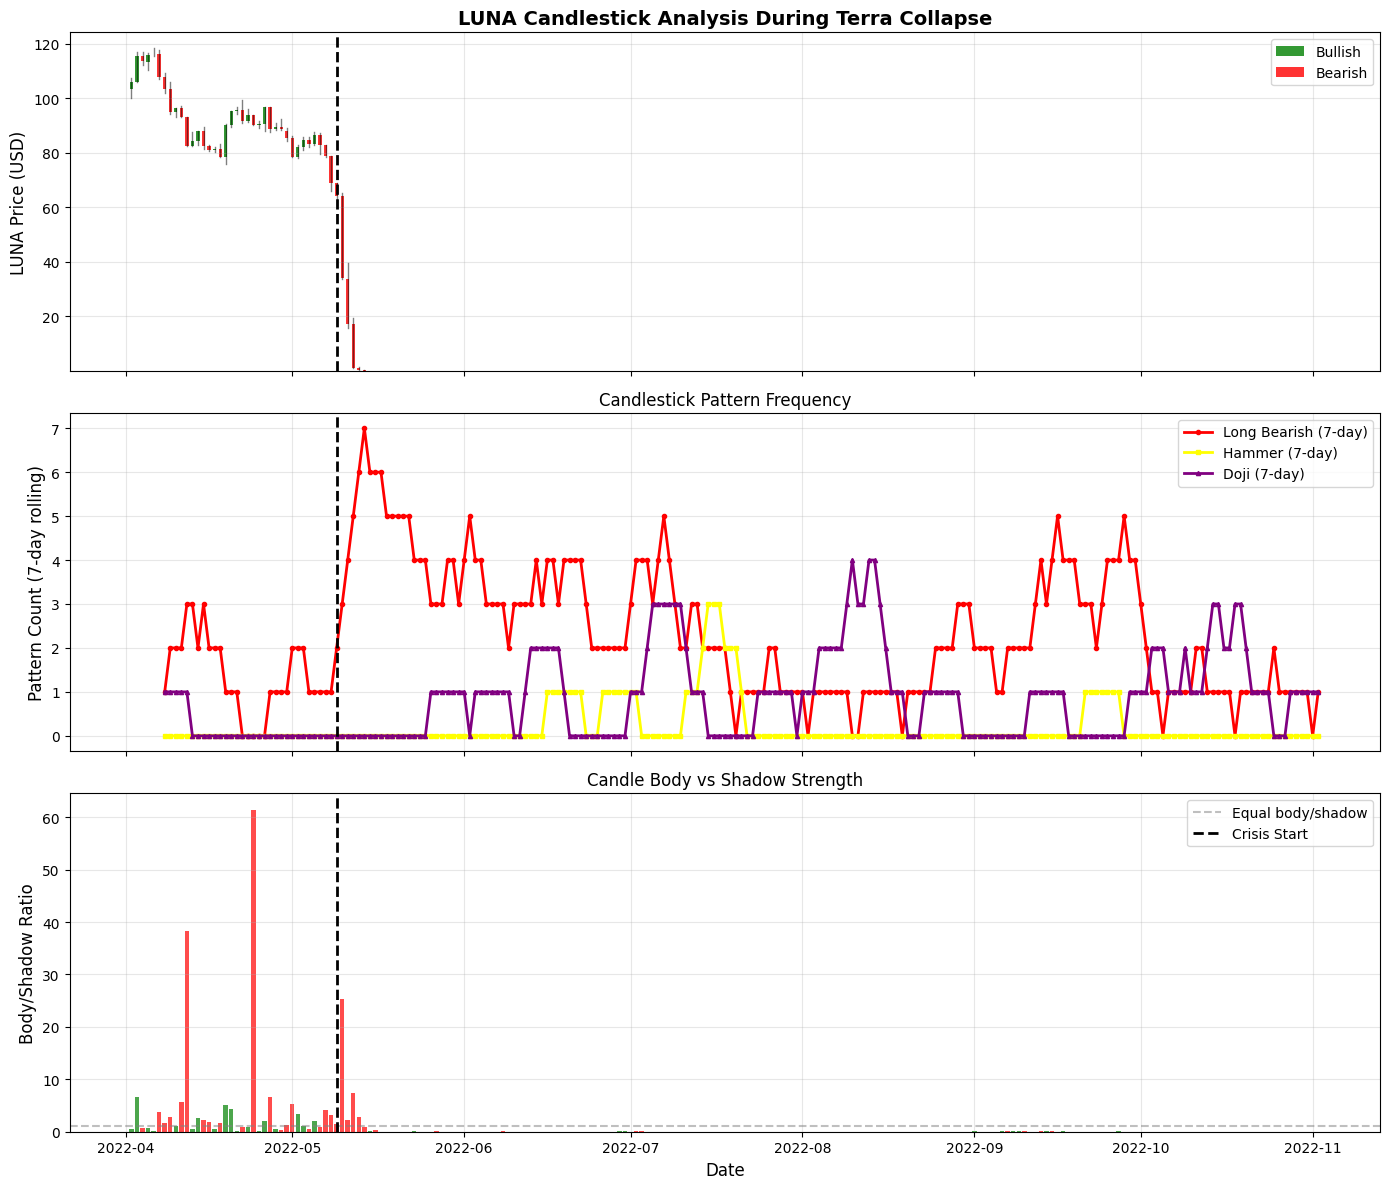

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# ========== Panel 1: Candlestick Chart ==========
ax1 = axes[0]

bullish = wluna['close'] >= wluna['open']
bearish = wluna['close'] < wluna['open']

# Bullish candles
ax1.bar(wluna.loc[bullish, 'datetime'], 
        wluna.loc[bullish, 'close'] - wluna.loc[bullish, 'open'],
        bottom=wluna.loc[bullish, 'open'],
        color='green', width=0.6, alpha=0.8, label='Bullish')

# Bearish candles
ax1.bar(wluna.loc[bearish, 'datetime'],
        wluna.loc[bearish, 'open'] - wluna.loc[bearish, 'close'],
        bottom=wluna.loc[bearish, 'close'],
        color='red', width=0.6, alpha=0.8, label='Bearish')

# Wicks
for idx, row in wluna.iterrows():
    ax1.plot([row['datetime'], row['datetime']], 
             [row['low'], row['high']], 
             color='black', linewidth=1, alpha=0.5)

ax1.axvline(x=pd.Timestamp('2022-05-09'), color='black', linestyle='--', linewidth=2)
ax1.set_ylabel('LUNA Price (USD)', fontsize=12)
ax1.set_title('LUNA Candlestick Analysis During Terra Collapse', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ========== Panel 2: Pattern Frequency ==========
ax2 = axes[1]

# Count patterns over time (rolling 7-day window)
wluna['long_bearish_count'] = wluna['long_bearish'].rolling(window=7).sum()
wluna['hammer_count'] = wluna['hammer'].rolling(window=7).sum()
wluna['doji_count'] = wluna['doji'].rolling(window=7).sum()

ax2.plot(wluna['datetime'], wluna['long_bearish_count'], 
         color='red', linewidth=2, label='Long Bearish (7-day)', marker='o', markersize=3)
ax2.plot(wluna['datetime'], wluna['hammer_count'], 
         color='yellow', linewidth=2, label='Hammer (7-day)', marker='s', markersize=3)
ax2.plot(wluna['datetime'], wluna['doji_count'], 
         color='purple', linewidth=2, label='Doji (7-day)', marker='^', markersize=3)

ax2.axvline(x=pd.Timestamp('2022-05-09'), color='black', linestyle='--', linewidth=2)
ax2.set_ylabel('Pattern Count (7-day rolling)', fontsize=12)
ax2.set_title('Candlestick Pattern Frequency', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# ========== Panel 3: Body vs Shadow Ratio ==========
ax3 = axes[2]

# Calculate ratios
wluna['body_shadow_ratio'] = wluna['body'] / (wluna['upper_shadow'] + wluna['lower_shadow'] + 0.001)

ax3.bar(wluna['datetime'], wluna['body_shadow_ratio'], 
        color=['green' if ct == 'bullish' else 'red' for ct in wluna['candle_type']],
        alpha=0.7)

ax3.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Equal body/shadow')
ax3.axvline(x=pd.Timestamp('2022-05-09'), color='black', linestyle='--', linewidth=2, label='Crisis Start')
ax3.set_ylabel('Body/Shadow Ratio', fontsize=12)
ax3.set_xlabel('Date', fontsize=12)
ax3.set_title('Candle Body vs Shadow Strength', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

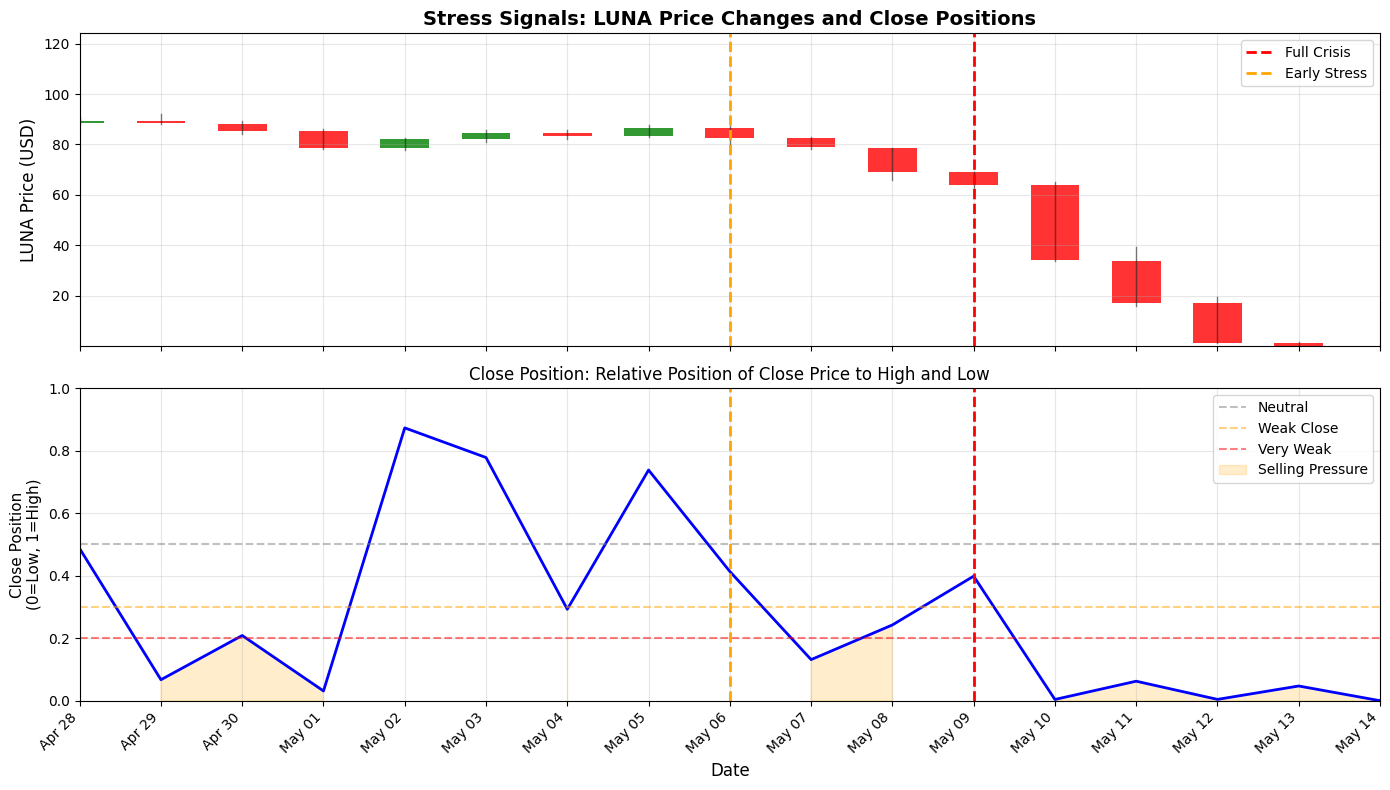

In [13]:
# Calculate where price closed in its daily range
wluna['close_position'] = (wluna['close'] - wluna['low']) / (wluna['high'] - wluna['low'])

# Calculate daily percentage change
wluna['daily_pct_change'] = wluna['close'].pct_change() * 100

# Create plot with 3 panels
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, 
                                     gridspec_kw={'height_ratios': [1, 1]})

# ========== Panel 1: Candlestick ==========
bullish = wluna['close'] >= wluna['open']
bearish = wluna['close'] < wluna['open']

ax1.bar(wluna.loc[bullish, 'datetime'], 
        wluna.loc[bullish, 'close'] - wluna.loc[bullish, 'open'],
        bottom=wluna.loc[bullish, 'open'],
        color='green', width=0.6, alpha=0.8)

ax1.bar(wluna.loc[bearish, 'datetime'],
        wluna.loc[bearish, 'open'] - wluna.loc[bearish, 'close'],
        bottom=wluna.loc[bearish, 'close'],
        color='red', width=0.6, alpha=0.8)

for idx, row in wluna.iterrows():
    ax1.plot([row['datetime'], row['datetime']], [row['low'], row['high']], 
             color='black', linewidth=1, alpha=0.5)

ax1.axvline(x=pd.Timestamp('2022-05-09'), color='red', linestyle='--', linewidth=2, label='Full Crisis')
ax1.axvline(x=pd.Timestamp('2022-05-06'), color='orange', linestyle='--', linewidth=2, label='Early Stress')
ax1.set_ylabel('LUNA Price (USD)', fontsize=12)
ax1.set_title('Stress Signals: LUNA Price Changes and Close Positions', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ========== Panel 2: Daily Percentage Change ==========
colors_pct = ['red' if x < 0 else 'green' for x in wluna['daily_pct_change']]
ax2.set_title('Early Warning Signs: Stress Before the Crisis', fontsize=14, fontweight='bold')
ax2.bar(wluna['datetime'], wluna['daily_pct_change'], color=colors_pct, alpha=0.7)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.axvline(x=pd.Timestamp('2022-05-09'), color='red', linestyle='--', linewidth=2)
ax2.axvline(x=pd.Timestamp('2022-05-06'), color='orange', linestyle='--', linewidth=2)
ax2.set_ylabel('Daily % Change', fontsize=11)
ax2.set_ylim(-105, 10)
ax2.grid(True, alpha=0.3)

# ========== Panel 3: Close Position ==========
ax3.plot(wluna['datetime'], wluna['close_position'], linewidth=2, color='blue')
ax3.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Neutral')
ax3.axhline(y=0.3, color='orange', linestyle='--', alpha=0.5, label='Weak Close')
ax3.axhline(y=0.2, color='red', linestyle='--', alpha=0.5, label='Very Weak')

# Highlight periods of weak closes
ax3.fill_between(wluna['datetime'], 0, wluna['close_position'],
                  where=(wluna['close_position'] < 0.3),
                  color='orange', alpha=0.2, label='Selling Pressure')

ax3.set_title("Close Position: Relative Position of Close Price to High and Low")
ax3.axvline(x=pd.Timestamp('2022-05-09'), color='red', linestyle='--', linewidth=2)
ax3.axvline(x=pd.Timestamp('2022-05-06'), color='orange', linestyle='--', linewidth=2)
ax3.set_ylabel('Close Position\n(0=Low, 1=High)', fontsize=11)
ax3.set_xlabel('Date', fontsize=12)
ax3.set_ylim(0, 1)
ax3.legend()
ax3.grid(True, alpha=0.3)

# ========== Format x-axis dates properly ==========
import matplotlib.dates as mdates

# Set date formatting for the bottom subplot (since sharex=True, it applies to all)
ax3.xaxis.set_major_locator(mdates.DayLocator(interval=1))  # Every day
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))  # Format as "May 09"

# Rotate labels
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Set x-axis limits
ax3.set_xlim(pd.Timestamp('2022-04-28'), pd.Timestamp('2022-05-14'))

plt.tight_layout()
plt.show()

In [9]:
wluna[wluna['datetime'] == pd.to_datetime('2022-05-09').date()]

,timestamp,open,high,low,close,datetime,body,upper_shadow,lower_shadow,candle_type,long_bearish,doji,hammer,long_bearish_count,hammer_count,doji_count,body_shadow_ratio,close_position,daily_pct_change
37,1652054400,69.01,69.01,60.68,64.0,2022-05-09,5.01,0.0,3.32,bearish,True,False,False,2.0,0.0,0.0,1.508582,0.398559,-7.246377
